In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Libraries

In [59]:
import os
import re
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense,Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# EDA & Data Cleaning

In [2]:
# Read dataset
con_df = pd.read_csv("/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv")
con_df.head(10)

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
5,5,credit_reporting,payment history missing credit report made mis...
6,6,credit_reporting,va date complaint experian credit bureau invol...
7,7,credit_reporting,account reported abbreviated name full name se...
8,8,credit_reporting,account reported abbreviated name full name se...
9,9,credit_reporting,usdoexxxx account reported abbreviated name fu...


In [3]:
con_df.tail(10)

,Unnamed: 0,product,narrative
162411,162411,retail_banking,zelle suspended account without cause banking ...
162412,162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...
162414,162414,debt_collection,zuntafi sent notice willing settle defaulted s...
162415,162415,debt_collection,name
162416,162416,debt_collection,name
162417,162417,credit_card,name
162418,162418,debt_collection,name
162419,162419,credit_card,name
162420,162420,credit_reporting,name


In [4]:
con_df.shape

(162421, 3)

In [5]:
con_df.size

487263

In [6]:
con_df.columns

Index(['Unnamed: 0', 'product', 'narrative'], dtype='object')

In [7]:
con_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  162421 non-null  int64 
 1   product     162421 non-null  object
 2   narrative   162411 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.7+ MB


In [8]:
con_df.describe(include = 'O')

,product,narrative
count,162421,162411
unique,5,124472
top,credit_reporting,victim identity notified collection creditor s...
freq,91179,739


In [9]:
# Check missing values
con_df.isnull().sum()

Unnamed: 0     0
product        0
narrative     10
dtype: int64

In [10]:
# Percentage of missing value
miss_percentage = (con_df.isnull().sum()/len(con_df))*100
miss_percentage.sort_values(ascending=False)

narrative     0.006157
Unnamed: 0    0.000000
product       0.000000
dtype: float64

In [11]:
# Remove missing narratives
con_df.dropna(subset=["narrative"], inplace=True)

In [12]:
# Drop Unnamed: 0 column
con_df.drop(columns = 'Unnamed: 0', axis = 1, inplace = True)

In [13]:
# Drop Duplicates
con_df = con_df.drop_duplicates()

In [14]:
con_df.duplicated().sum()

np.int64(0)

In [15]:
# Filter short narratives
con_df = con_df[con_df["narrative"].str.split().str.len() >= 3]

In [16]:
# Reset the dataframe index
con_df.reset_index(drop=True, inplace=True)

In [17]:
con_df

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...
...,...,...
124518,credit_reporting,zales comenity bank closed sold account report...
124519,retail_banking,zelle suspended account without cause banking ...
124520,debt_collection,zero contact made debt supposedly resolved fou...
124521,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...


In [18]:
# Class Distribution
con_df['product'].value_counts()

product
credit_reporting       56218
debt_collection        21076
mortgages_and_loans    18754
credit_card            15022
retail_banking         13453
Name: count, dtype: int64

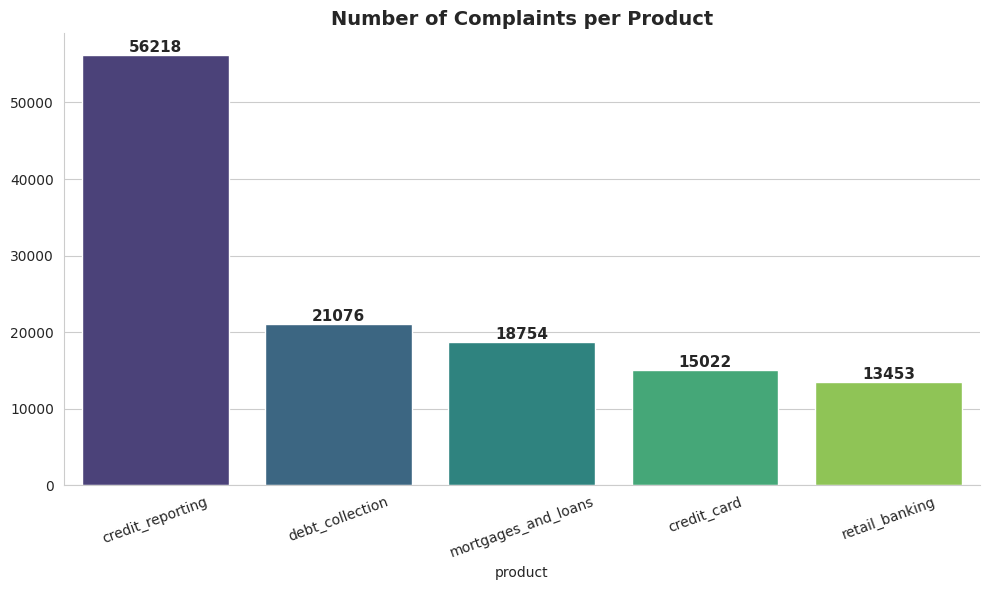

In [19]:
# Plot Class Distribution
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

product_counts = con_df["product"].value_counts()

ax = sns.barplot(
    x=product_counts.index,
    y=product_counts.values,
    palette="viridis"
)

plt.title("Number of Complaints per Product", fontsize=14, fontweight="bold")

plt.xticks(rotation=20)

# Display values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

In [20]:
# Calculate the word count for each narrative
word_count = con_df['narrative'].apply(lambda x : len(str(x).split()))
print("Word Count per Narrative: ", '\n', word_count)

Word Count per Narrative:  
 0         230
1         132
2         173
3         131
4         123
         ... 
124518     70
124519     17
124520     25
124521     16
124522     68
Name: narrative, Length: 124523, dtype: int64


In [21]:
# Describe word count
word_count.describe()

count    124523.000000
mean         87.221847
std         110.903128
min           3.000000
25%          31.000000
50%          58.000000
75%         104.000000
max        2685.000000
Name: narrative, dtype: float64

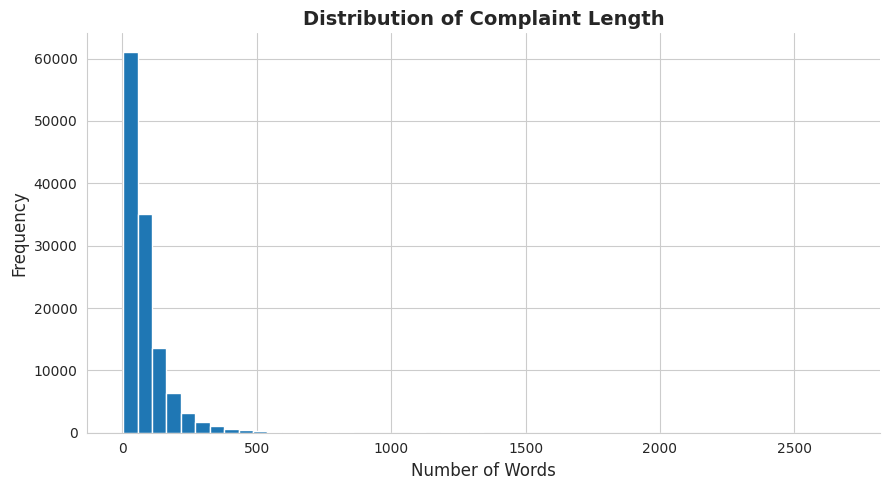

In [22]:
# Plot the complaint length distribution
plt.figure(figsize=(9,5))
sns.set_style("whitegrid")

plt.hist(word_count, bins=50)

plt.title("Distribution of Complaint Length", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

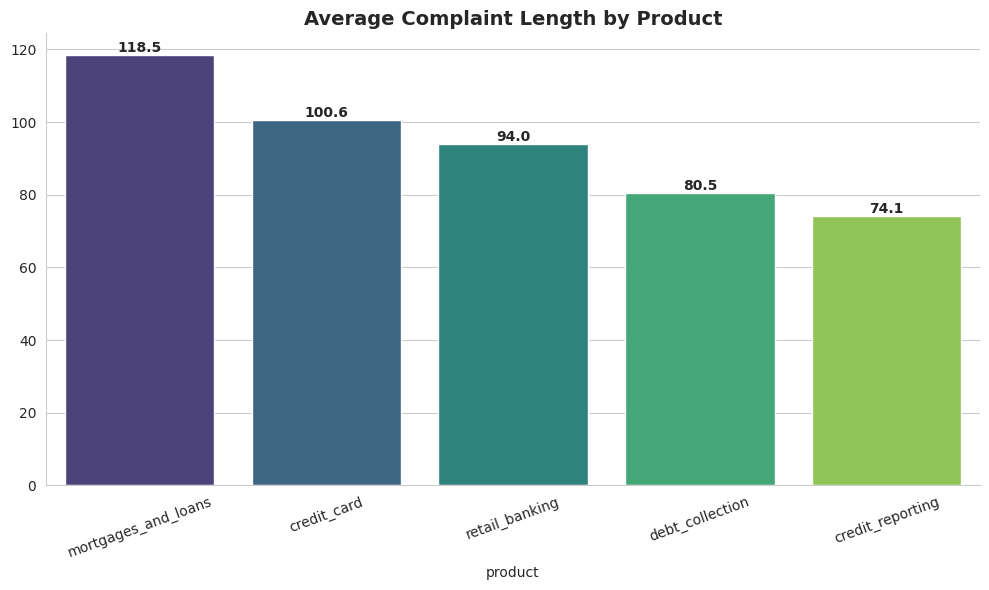

In [23]:
# Plot average complaint length by product
word_count_df = pd.DataFrame({
    "product": con_df["product"],
    "word_count": con_df["narrative"].apply(lambda x: len(str(x).split()))
})

avg_words = word_count_df.groupby("product")["word_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x=avg_words.index,
    y=avg_words.values,
    palette="viridis"
)

plt.title("Average Complaint Length by Product", fontsize=14, fontweight="bold")

plt.xticks(rotation=20)

# Display values on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

In [24]:
# Extract the most frequent words
all_words = " ".join(con_df["narrative"]).split()

word_freq = Counter(all_words)

# Get top 20 words
top_words = word_freq.most_common(20)

top_words_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

print(top_words_df)

           Word  Frequency
0       account     252895
1        credit     239621
2        report     124290
3       payment     118363
4   information     104294
5          time      73354
6         would      72341
7          loan      70670
8       company      67882
9          card      66769
10         bank      65814
11         debt      62523
12    reporting      62507
13          day      61027
14     received      60298
15       letter      56363
16         told      53516
17         sent      49850
18        never      49399
19         call      49075


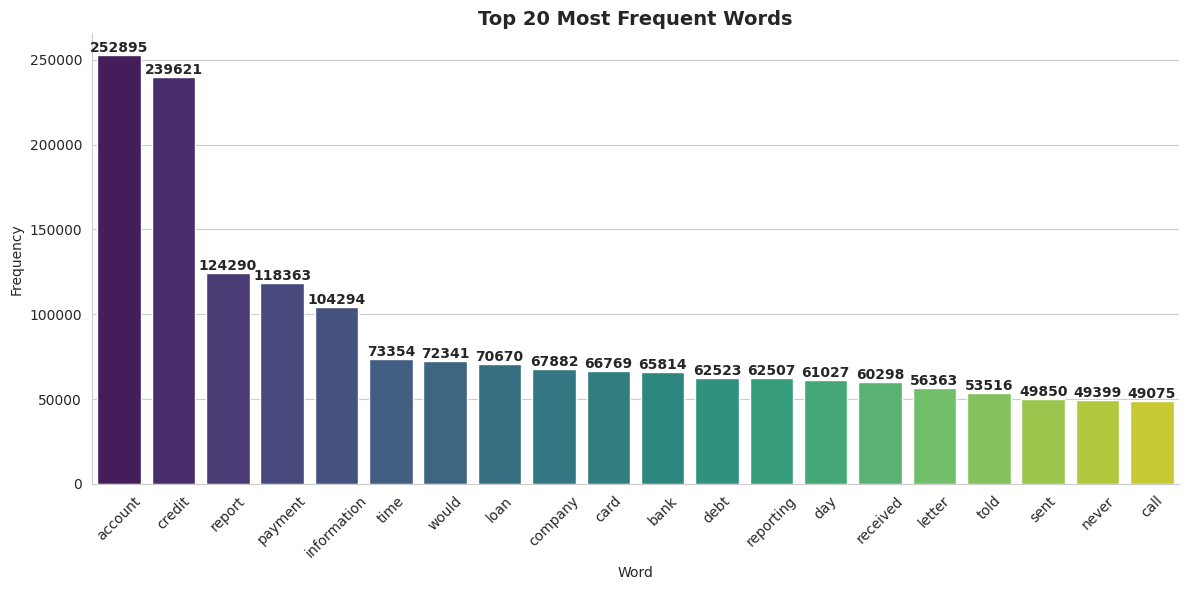

In [25]:
# Plot the most frequent words
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=top_words_df,
    x="Word",
    y="Frequency",
    palette="viridis"
)

plt.title("Top 20 Most Frequent Words", fontsize=14, fontweight="bold")

plt.xticks(rotation=45)

# Display values
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

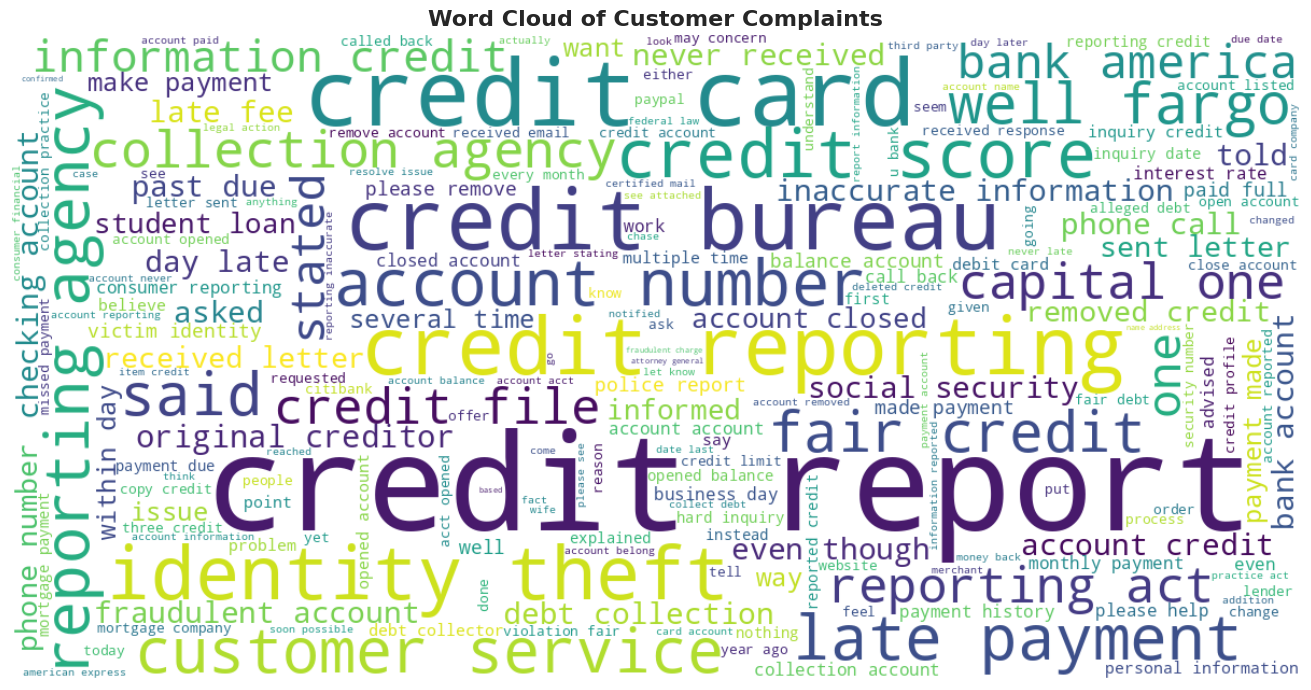

In [26]:
# Generate a word cloud from complaints
text = " ".join(con_df["narrative"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title(
    "Word Cloud of Customer Complaints",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Data Preprocessing

In [27]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [28]:
# Define the text preprocessing function
def preprocess_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = [
        word for word in text.split()
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [29]:
# Apply preprocess function
con_df["processed_text"] = con_df["narrative"].apply(preprocess_text)

In [30]:
con_df[["narrative", "processed_text"]].head(10)

,narrative,processed_text
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...
5,payment history missing credit report made mis...,payment history missing credit report made mis...
6,va date complaint experian credit bureau invol...,va date complaint experian credit bureau invol...
7,account reported abbreviated name full name se...,account reported abbreviated name full name se...
8,account reported abbreviated name full name se...,account reported abbreviated name full name se...
9,usdoexxxx account reported abbreviated name fu...,usdoexxxx account reported abbreviated name fu...


In [31]:
# Define the input features and target labels
X = con_df["processed_text"]
y = con_df["product"]

In [32]:
# Apply Label Encoding
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [33]:
# Create the label mapping table
mapping_result = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Label": range(len(label_encoder.classes_))
})

mapping_result

,Class,Label
0,credit_card,0
1,credit_reporting,1
2,debt_collection,2
3,mortgages_and_loans,3
4,retail_banking,4


In [34]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [35]:
print("Train_set Size:", len(X_train))
print("Test_set Size :", len(X_test))

Train_set Size: 99618
Test_set Size : 24905


In [36]:
# Build the tokenizer vocabulary
max_words = 20000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [37]:
# Convert text into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [38]:
# Analyze sequence lengths
sequence_lengths = [len(seq) for seq in X_train_seq]

pd.Series(sequence_lengths).describe()

count    99618.000000
mean        87.291985
std        112.038307
min          3.000000
25%         30.000000
50%         58.000000
75%        104.000000
max       2568.000000
dtype: float64

In [39]:
pd.Series(sequence_lengths).quantile([0.90, 0.95, 0.99])

0.90    180.0
0.95    254.0
0.99    503.0
dtype: float64

In [40]:
# Padding 
max_length = 256

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [41]:
# Calculate the vocabulary size
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

print(f"Vocab Size: {vocab_size}")

Vocab Size: 20000


# Models

## SimpleRNN

In [82]:
# Simple RNN model
num_classes = len(label_encoder.classes_)

simple_rnn_model = Sequential([

    Embedding(input_dim=vocab_size,output_dim=128),

    Bidirectional(SimpleRNN(128,dropout=0.2,recurrent_dropout=0.2)),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

In [83]:
simple_rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
simple_rnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [87]:
# Apply Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [88]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [89]:
# Training
history_rnn = simple_rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 196s 154ms/step - accuracy: 0.1893 - loss: 1.6388 - val_accuracy: 0.2146 - val_loss: 1.6068
Epoch 2/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 193s 155ms/step - accuracy: 0.1859 - loss: 1.6195 - val_accuracy: 0.1662 - val_loss: 1.6082
Epoch 3/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 191s 153ms/step - accuracy: 0.1849 - loss: 1.6146 - val_accuracy: 0.1052 - val_loss: 1.6121
Epoch 4/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 192s 154ms/step - accuracy: 0.1494 - loss: 1.6134 - val_accuracy: 0.1679 - val_loss: 1.6087


In [90]:
# Evaluation
y_pred_prob = simple_rnn_model.predict(X_test_pad)
y_pred = y_pred_prob.argmax(axis=1)

779/779 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step


In [91]:
# Calculate Accuracy, Precision, Recall, F1-score
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred, average="weighted"))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Accuracy : 0.21300943585625376
Precision: 0.2860274596667984
Recall   : 0.21300943585625376
F1-score : 0.18112111556958974

Classification Report:

                     precision    recall  f1-score   support

        credit_card       0.00      0.00      0.00      3004
   credit_reporting       0.48      0.14      0.21     11244
    debt_collection       0.18      0.36      0.24      4215
mortgages_and_loans       0.17      0.59      0.27      3751
     retail_banking       0.12      0.03      0.05      2691

           accuracy                           0.21     24905
          macro avg       0.19      0.22      0.15     24905
       weighted avg       0.29      0.21      0.18     24905



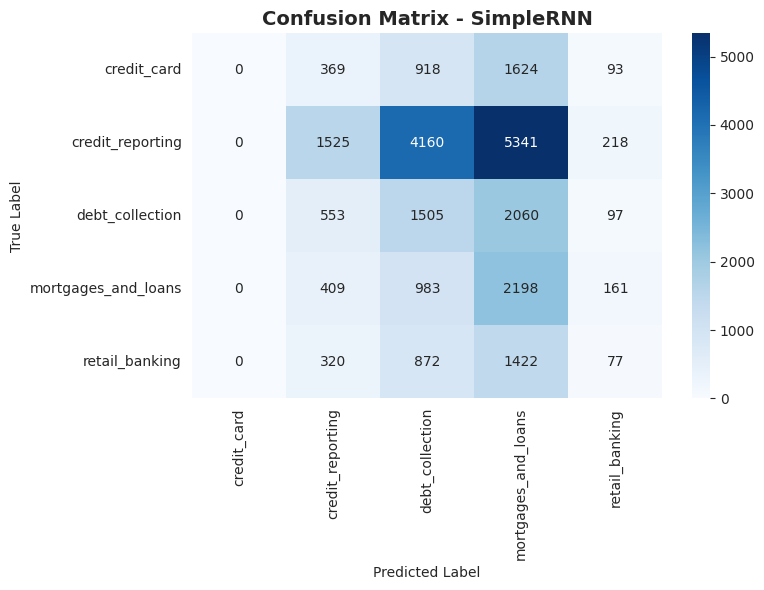

In [92]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - SimpleRNN", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [94]:
# Save Results
rnn_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1-score": f1_score(y_test, y_pred, average="weighted")
}

## LSTM

In [95]:
# LSTM model
num_classes = len(label_encoder.classes_)

lstm_model = Sequential([
    
    Embedding(input_dim=vocab_size,output_dim=128,mask_zero=True),

    Bidirectional(LSTM(128,dropout=0.3,recurrent_dropout=0.3)),

    Dense(64,activation="relu"),

    Dropout(0.5),

    Dense(num_classes,activation="softmax")
])

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [96]:
lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [97]:
# Training
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 1012s 804ms/step - accuracy: 0.7434 - loss: 0.6920 - val_accuracy: 0.8308 - val_loss: 0.4938
Epoch 2/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 967s 776ms/step - accuracy: 0.8325 - loss: 0.4756 - val_accuracy: 0.8242 - val_loss: 0.4986
Epoch 3/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 966s 775ms/step - accuracy: 0.8466 - loss: 0.4249 - val_accuracy: 0.8286 - val_loss: 0.4901
Epoch 4/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 965s 774ms/step - accuracy: 0.8551 - loss: 0.3873 - val_accuracy: 0.8323 - val_loss: 0.4833
Epoch 5/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 969s 778ms/step - accuracy: 0.8635 - loss: 0.3551 - val_accuracy: 0.8241 - val_loss: 0.5027
Epoch 6/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 973s 781ms/step - accuracy: 0.8728 - loss: 0.3259 - val_accuracy: 0.8314 - val_loss: 0.5153
Epoch 7/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 974s 781ms/step - accuracy: 0.8776 - loss: 0.3013 - val_accuracy: 0.8345 - val_loss: 0.5243


In [100]:
# Prediction
y_pred_prob_lstm = lstm_model.predict(X_test_pad)

y_pred_lstm = np.argmax(y_pred_prob_lstm, axis=1)

779/779 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step


In [102]:
# Calculate Accuracy, Precision, Recall, F1-score
accuracy = accuracy_score(y_test, y_pred_lstm)
precision = precision_score(y_test, y_pred_lstm, average="weighted")
recall = recall_score(y_test, y_pred_lstm, average="weighted")
f1 = f1_score(y_test, y_pred_lstm, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8276
Precision: 0.8390
Recall   : 0.8276
F1-score : 0.8297


In [103]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=label_encoder.classes_)
)

                     precision    recall  f1-score   support

        credit_card       0.71      0.84      0.77      3004
   credit_reporting       0.93      0.80      0.86     11244
    debt_collection       0.73      0.81      0.77      4215
mortgages_and_loans       0.78      0.88      0.83      3751
     retail_banking       0.84      0.87      0.85      2691

           accuracy                           0.83     24905
          macro avg       0.80      0.84      0.82     24905
       weighted avg       0.84      0.83      0.83     24905



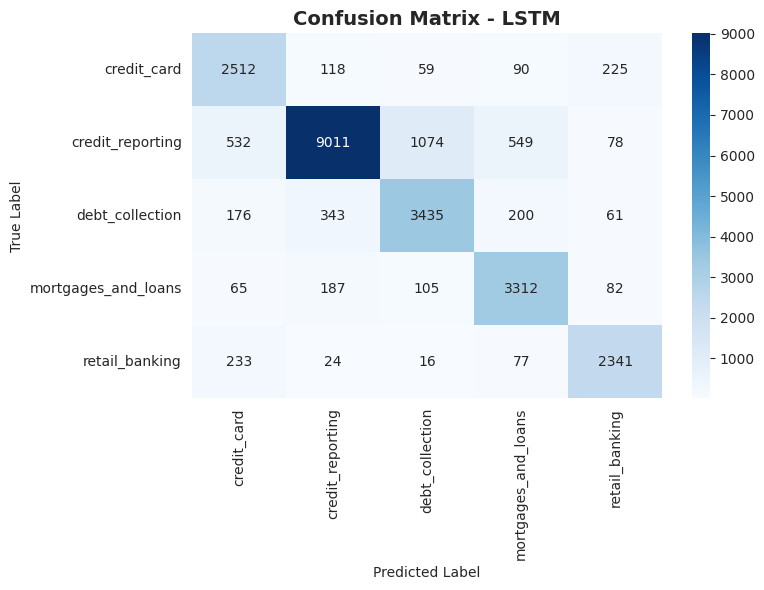

In [104]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - LSTM", fontsize=14, fontweight="bold")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

In [105]:
# Save Results
lstm_results = {
    "Model": "LSTM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

## GRU

In [107]:
# GRU model
num_classes = len(label_encoder.classes_)

gru_model = Sequential([

    Embedding(input_dim=vocab_size,output_dim=128,mask_zero=True),

    Bidirectional(GRU(units=128,dropout=0.3,recurrent_dropout=0.3)),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [108]:
gru_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [109]:
# Training
history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 823s 654ms/step - accuracy: 0.7469 - loss: 0.7025 - val_accuracy: 0.8164 - val_loss: 0.5206
Epoch 2/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 812s 652ms/step - accuracy: 0.8306 - loss: 0.4759 - val_accuracy: 0.8268 - val_loss: 0.4894
Epoch 3/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 823s 661ms/step - accuracy: 0.8471 - loss: 0.4161 - val_accuracy: 0.8403 - val_loss: 0.4481
Epoch 4/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 821s 659ms/step - accuracy: 0.8596 - loss: 0.3747 - val_accuracy: 0.8254 - val_loss: 0.4960
Epoch 5/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 813s 653ms/step - accuracy: 0.8682 - loss: 0.3386 - val_accuracy: 0.8437 - val_loss: 0.4505
Epoch 6/20
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 816s 655ms/step - accuracy: 0.8783 - loss: 0.3065 - val_accuracy: 0.8371 - val_loss: 0.4728


In [110]:
# Prediction
y_pred_prob_gru = gru_model.predict(X_test_pad)

y_pred_gru = np.argmax(y_pred_prob_gru, axis=1)

779/779 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step


In [111]:
# Calculate Accuracy, Precision, Recall, F1-score
accuracy = accuracy_score(y_test, y_pred_gru)
precision = precision_score(y_test, y_pred_gru, average="weighted")
recall = recall_score(y_test, y_pred_gru, average="weighted")
f1 = f1_score(y_test, y_pred_gru, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8353
Precision: 0.8449
Recall   : 0.8353
F1-score : 0.8374


In [112]:
# Classification Report 
print(classification_report(
    y_test,
    y_pred_gru,
    target_names=label_encoder.classes_)
     )

                     precision    recall  f1-score   support

        credit_card       0.72      0.86      0.78      3004
   credit_reporting       0.92      0.82      0.87     11244
    debt_collection       0.74      0.83      0.78      4215
mortgages_and_loans       0.80      0.87      0.83      3751
     retail_banking       0.87      0.85      0.86      2691

           accuracy                           0.84     24905
          macro avg       0.81      0.84      0.83     24905
       weighted avg       0.84      0.84      0.84     24905



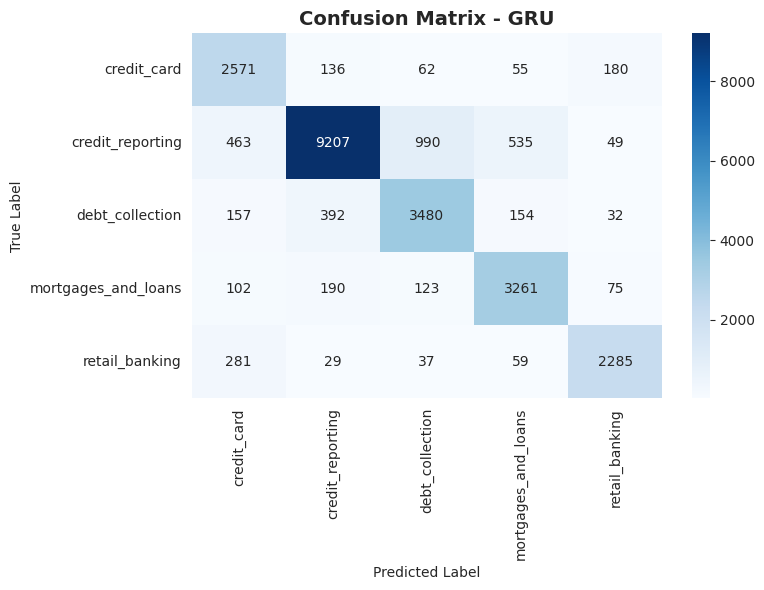

In [113]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - GRU", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [114]:
# Save Results
gru_results = {
    "Model": "GRU",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

## Fine-Tuned Transformer 

In [42]:
# Create HuggingFace Dataset
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

train_dataset = Dataset.from_pandas(train_df)

test_dataset = Dataset.from_pandas(test_df)

In [45]:
# Tokenization
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [46]:
train_dataset = train_dataset.map(tokenize, batched=True)

test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/99618 [00:00<?, ? examples/s]

Map:   0%|          | 0/24905 [00:00<?, ? examples/s]

In [47]:
# Remove unnecessary columns
train_dataset = train_dataset.remove_columns(["text"])

test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")

test_dataset.set_format("torch")

In [48]:
# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [49]:
# Training Arguments
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    report_to="none"
)

In [50]:
# Initialize the model trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [51]:
# Training
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.820337,0.823192
2,0.685589,0.759610
3,0.531042,0.816139


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=18681, training_loss=0.734744877996731, metrics={'train_runtime': 5060.1423, 'train_samples_per_second': 59.06, 'train_steps_per_second': 3.692, 'total_flos': 1.979526498365952e+16, 'train_loss': 0.734744877996731, 'epoch': 3.0})

In [52]:
# Prediction
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions,axis=1)

In [53]:
# Calculate Accuracy, Precision, Recall, F1_score
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test,y_pred,average="weighted")

recall = recall_score(y_test,y_pred,average="weighted")

f1 = f1_score(y_test,y_pred,average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8675
Precision: 0.8672
Recall   : 0.8675
F1-score : 0.8672


In [54]:
# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

                     precision    recall  f1-score   support

        credit_card       0.82      0.82      0.82      3004
   credit_reporting       0.89      0.91      0.90     11244
    debt_collection       0.82      0.79      0.81      4215
mortgages_and_loans       0.88      0.84      0.86      3751
     retail_banking       0.89      0.87      0.88      2691

           accuracy                           0.87     24905
          macro avg       0.86      0.85      0.85     24905
       weighted avg       0.87      0.87      0.87     24905



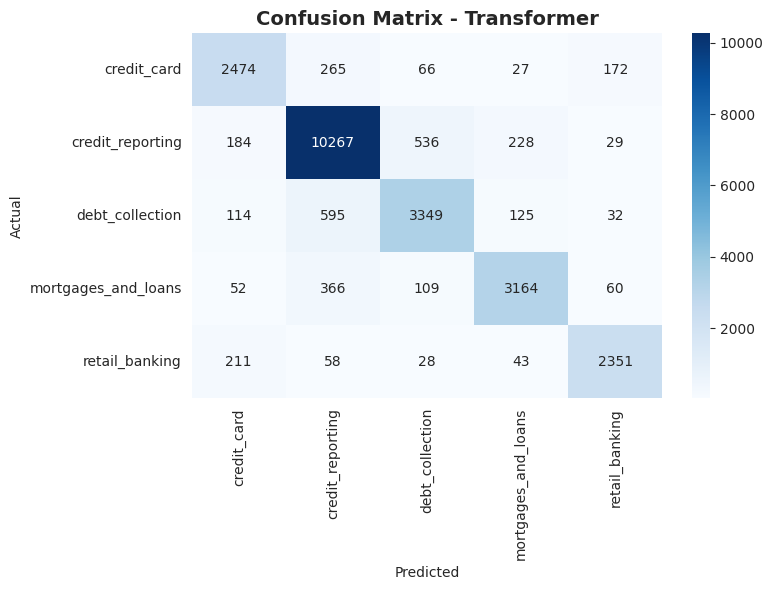

In [55]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Confusion Matrix - Transformer",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

In [56]:
# Save Results
transformer_results = {
    "Model": "DistilBERT Transformer",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

In [57]:
# Save model
trainer.save_model("transformer_model")
tokenizer.save_pretrained("transformer_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('transformer_model/tokenizer_config.json', 'transformer_model/tokenizer.json')

In [58]:
shutil.make_archive(
    "/kaggle/working/transformer_model",
    'zip',
    "/kaggle/working/transformer_model"
)

'/kaggle/working/transformer_model.zip'